In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import pandas as pd
import numpy as np
import ast
import copy
import torch
import torch.nn.functional as F
from torch.optim import AdamW
from torch.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Dataset
from transformers import get_linear_schedule_with_warmup, AutoTokenizer
from sentence_transformers import SentenceTransformer, InputExample
from sentence_transformers.losses import MultipleNegativesRankingLoss
from sklearn.model_selection import train_test_split
import gc

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Memorie GPU disponibila: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB')

/tmp/ipykernel_58/1912119922.py:12: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers.losses import MultipleNegativesRankingLoss


Device: cuda
Memorie GPU disponibila: 15.5 GB


In [2]:
DATA_PATH   = '/kaggle/input/datasets/catalinalupu/movies-with-review-summaries/movies_with_review_summaries.csv'
OUTPUT_PATH = '/kaggle/working/'

df = pd.read_csv(DATA_PATH)
print(f'Filme incarcate: {len(df):,}')

for col in ['overview', 'overview_summary', 'review_summary', 'tagline',
            'genres', 'keywords', 'cast']:
    df[col] = df[col].fillna('').astype(str).str.strip().replace('nan', '')

Filme incarcate: 40,197


In [3]:
def parse_cast(cast_raw, max_actors=4):
    try:
        actors = ast.literal_eval(cast_raw)
        if isinstance(actors, list):
            return ', '.join(a['name'] for a in actors[:max_actors] if 'name' in a)
    except:
        pass
    return ''

def parse_keywords(kw_raw, max_kw=10):
    try:
        parsed = ast.literal_eval(kw_raw)
        if isinstance(parsed, list):
            return ', '.join(str(k) for k in parsed[:max_kw])
    except:
        pass
    return ''

def clean_overview_summary(title, ovs):
    t = str(title).strip()
    s = str(ovs).strip()
    if s.lower().startswith(t.lower()):
        s = s[len(t):].lstrip('. ').strip()
    return s

def build_doc_text(row):
    parts = [str(row.get('title', '')).strip() + '.']
    ovs   = clean_overview_summary(row.get('title', ''), row.get('overview_summary', ''))
    ov    = str(row.get('overview', '')).replace('nan', '').strip()
    plot  = ovs if ovs else ov
    if plot:
        parts.append('Plot: ' + plot)
    rev = str(row.get('review_summary', '')).replace('nan', '').strip()
    if rev:
        parts.append('Critics: ' + rev)
    genres = str(row.get('genres', '')).replace('nan', '').strip()
    if genres:
        parts.append('Genres: ' + genres)
    kw = parse_keywords(str(row.get('keywords', '')))
    if kw:
        parts.append('Keywords: ' + kw)
    cast = parse_cast(str(row.get('cast', '')))
    if cast:
        parts.append('Cast: ' + cast)
    return ' '.join(parts)

df['doc_text'] = df.apply(build_doc_text, axis=1)
mask = (df['tagline'] != '') & (df['doc_text'] != '')
df_valid = df[mask].copy().reset_index(drop=True)
print(f'Filme valide (cu tagline si doc_text): {len(df_valid):,}')

Filme valide (cu tagline si doc_text): 40,197


In [4]:
train_df, temp_df = train_test_split(df_valid, test_size=0.20, random_state=42)
val_df,   test_df = train_test_split(temp_df,  test_size=0.50, random_state=42)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')

Train: 32,157 | Val: 4,020 | Test: 4,020


In [5]:
BGE_PREFIX = 'Represent this sentence: '

train_examples = [
    InputExample(texts=[BGE_PREFIX + row['tagline'], row['doc_text']])
    for _, row in train_df.iterrows()
    if len(str(row['tagline']).split()) >= 3
]
print(f'Perechi antrenament MNR: {len(train_examples):,}')

Perechi antrenament MNR: 31,806


In [6]:
def compute_hit_at_k(model, eval_df, ks=(1, 3, 5, 10, 20), batch_size=512):
    queries = [BGE_PREFIX + t for t in eval_df['tagline'].tolist()]
    docs    = eval_df['doc_text'].tolist()

    q_emb = model.encode(queries, batch_size=batch_size, convert_to_numpy=True,
                         normalize_embeddings=True, show_progress_bar=False)
    d_emb = model.encode(docs,    batch_size=batch_size, convert_to_numpy=True,
                         normalize_embeddings=True, show_progress_bar=False)

    results = {k: 0 for k in ks}
    n = len(eval_df)
    for start in range(0, n, batch_size):
        end  = min(start + batch_size, n)
        sims = q_emb[start:end] @ d_emb.T
        for i, global_i in enumerate(range(start, end)):
            row_sims = sims[i]
            rank = int((row_sims > row_sims[global_i]).sum()) + 1
            for k in ks:
                if rank <= k:
                    results[k] += 1
    return {k: results[k] / n for k in ks}


def compute_hit_at_k_full_pool(model, eval_df, full_df, ks=(1, 3, 5, 10, 20), batch_size=512):
    queries  = [BGE_PREFIX + t for t in eval_df['tagline'].tolist()]
    all_docs = full_df['doc_text'].tolist()

    full_id_to_idx = {mid: i for i, mid in enumerate(full_df['movie_id'].tolist())}
    eval_indices   = [full_id_to_idx[mid] for mid in eval_df['movie_id'].tolist()]

    q_emb = model.encode(queries,  batch_size=batch_size, convert_to_numpy=True,
                         normalize_embeddings=True, show_progress_bar=False)
    d_emb = model.encode(all_docs, batch_size=batch_size, convert_to_numpy=True,
                         normalize_embeddings=True, show_progress_bar=False)

    results = {k: 0 for k in ks}
    n = len(eval_df)
    for start in range(0, n, batch_size):
        end  = min(start + batch_size, n)
        sims = q_emb[start:end] @ d_emb.T
        for i, global_i in enumerate(range(start, end)):
            correct = eval_indices[global_i]
            rank    = int((sims[i] > sims[i][correct]).sum()) + 1
            for k in ks:
                if rank <= k:
                    results[k] += 1
    return {k: results[k] / n for k in ks}

In [7]:
try:
    del sbert, loss_fn, optimizer, scheduler, scaler
except:
    pass
gc.collect()
torch.cuda.empty_cache()
print(f'Memorie GPU libera: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB')

EPOCHS_MNR = 10
BATCH_SIZE = 128
LR_MNR     = 2e-5
PATIENCE   = 2

sbert     = SentenceTransformer('BAAI/bge-base-en-v1.5', device=str(device))
loss_fn   = MultipleNegativesRankingLoss(sbert)
tokenizer = AutoTokenizer.from_pretrained('BAAI/bge-base-en-v1.5')
sbert[0].auto_model.gradient_checkpointing_enable()

def tokenize_texts(texts):
    encoded = tokenizer(texts, padding=True, truncation=True,
                        max_length=256, return_tensors='pt')
    return {k: v.to(device) for k, v in encoded.items()}

loader       = DataLoader(train_examples, shuffle=True, batch_size=BATCH_SIZE,
                          collate_fn=lambda x: x)
total_steps  = len(loader) * EPOCHS_MNR
warmup_steps = int(0.1 * total_steps)

optimizer = AdamW(sbert.parameters(), lr=LR_MNR, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
scaler    = GradScaler('cuda')

best_hit10_mnr    = 0.0
best_model_state  = None
epochs_no_improve = 0
history_mnr       = []

for epoch in range(1, EPOCHS_MNR + 1):
    sbert.train()
    total_loss = 0.0

    for batch in loader:
        optimizer.zero_grad()
        with autocast('cuda'):
            sentence_features = [
                tokenize_texts([ex.texts[0] for ex in batch]),
                tokenize_texts([ex.texts[1] for ex in batch])
            ]
            loss = loss_fn(sentence_features, None)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(loader)

    sbert.eval()
    with torch.no_grad():
        val_hits_small = compute_hit_at_k(sbert, val_df)
        print(f'  [Epoca {epoch}] Calculez Hit@K pe pool complet...')
        val_hits_full  = compute_hit_at_k_full_pool(sbert, val_df, df_valid)

    val_hit10_full = val_hits_full[10]
    history_mnr.append({
        'epoch':           epoch,
        'loss':            avg_loss,
        'val_hit10_small': val_hits_small[10],
        'val_hit10_full':  val_hit10_full
    })

    print(f'MNR Epoca {epoch}/{EPOCHS_MNR} | Loss: {avg_loss:.4f}')
    print(f'  Pool mic     — Hit@1={val_hits_small[1]:.1%} Hit@10={val_hits_small[10]:.1%}')
    print(f'  Pool complet — Hit@1={val_hits_full[1]:.1%} Hit@5={val_hits_full[5]:.1%} '
          f'Hit@10={val_hit10_full:.1%} Hit@20={val_hits_full[20]:.1%}')

    if val_hit10_full > best_hit10_mnr:
        best_hit10_mnr    = val_hit10_full
        best_model_state  = copy.deepcopy(sbert.state_dict())
        epochs_no_improve = 0
        print(f'  -> Model MNR salvat (Full Pool Hit@10={best_hit10_mnr:.1%})')
    else:
        epochs_no_improve += 1
        print(f'  -> Fara imbunatatire pe pool complet ({epochs_no_improve}/{PATIENCE})')
        if epochs_no_improve >= PATIENCE:
            print(f'Early stopping la epoca {epoch}.')
            break

print(f'\nCel mai bun Full Pool Hit@10 MNR: {best_hit10_mnr:.1%}')

Memorie GPU libera: 15.5 GB


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


  [Epoca 1] Calculez Hit@K pe pool complet...
MNR Epoca 1/10 | Loss: 2.8779
  Pool mic     — Hit@1=18.1% Hit@10=37.5%
  Pool complet — Hit@1=9.0% Hit@5=15.5% Hit@10=19.8% Hit@20=24.2%
  -> Model MNR salvat (Full Pool Hit@10=19.8%)
  [Epoca 2] Calculez Hit@K pe pool complet...
MNR Epoca 2/10 | Loss: 2.2795
  Pool mic     — Hit@1=19.2% Hit@10=39.0%
  Pool complet — Hit@1=9.7% Hit@5=16.7% Hit@10=20.6% Hit@20=25.2%
  -> Model MNR salvat (Full Pool Hit@10=20.6%)
  [Epoca 3] Calculez Hit@K pe pool complet...
MNR Epoca 3/10 | Loss: 1.9676
  Pool mic     — Hit@1=19.1% Hit@10=39.7%
  Pool complet — Hit@1=9.3% Hit@5=17.0% Hit@10=21.1% Hit@20=25.4%
  -> Model MNR salvat (Full Pool Hit@10=21.1%)
  [Epoca 4] Calculez Hit@K pe pool complet...
MNR Epoca 4/10 | Loss: 1.7360
  Pool mic     — Hit@1=19.0% Hit@10=39.6%
  Pool complet — Hit@1=9.2% Hit@5=16.9% Hit@10=20.7% Hit@20=25.3%
  -> Fara imbunatatire pe pool complet (1/2)
  [Epoca 5] Calculez Hit@K pe pool complet...
MNR Epoca 5/10 | Loss: 1.5512
  

In [8]:
sbert.load_state_dict(best_model_state)
sbert.eval()

print('Encodez tagline-urile si documentele din train pentru mining...')
train_taglines  = [BGE_PREFIX + r['tagline'] for _, r in train_df.iterrows()]
train_docs_list = train_df['doc_text'].tolist()

def parse_genres_set(g):
    try:
        lst = ast.literal_eval(g)
        if isinstance(lst, list):
            return set(str(x).lower().strip() for x in lst)
    except:
        pass
    return set(g.lower().split(',')) if g else set()

train_genres = [parse_genres_set(g) for g in train_df['genres'].tolist()]

MINE_BATCH = 512
with torch.no_grad():
    q_emb = sbert.encode(train_taglines,  batch_size=MINE_BATCH,
                         convert_to_numpy=True, normalize_embeddings=True,
                         show_progress_bar=True)
    d_emb = sbert.encode(train_docs_list, batch_size=MINE_BATCH,
                         convert_to_numpy=True, normalize_embeddings=True,
                         show_progress_bar=True)

print(f'Embeddings calculate. Shape: {q_emb.shape}')

TOP_K       = 60
SAME_GENRE  = 3
CROSS_GENRE = 3
triplets    = []
n           = len(train_df)

for i in range(n):
    sims    = q_emb[i] @ d_emb.T
    sims[i] = -1.0
    top_idx = np.argsort(sims)[::-1][:TOP_K]

    g_i   = train_genres[i]
    same  = []
    cross = []

    for j in top_idx:
        if len(same) < SAME_GENRE and (g_i & train_genres[j]):
            same.append(j)
        elif len(cross) < CROSS_GENRE and not (g_i & train_genres[j]):
            cross.append(j)
        if len(same) >= SAME_GENRE and len(cross) >= CROSS_GENRE:
            break

    for j in same:
        triplets.append((i, i, int(j)))
    for j in cross:
        triplets.append((i, i, int(j)))

print(f'Triplete minate: {len(triplets):,}')

Encodez tagline-urile si documentele din train pentru mining...


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Embeddings calculate. Shape: (32157, 768)
Triplete minate: 179,137


In [9]:
class TripletDataset(Dataset):
    def __init__(self, triplets, taglines, docs):
        self.triplets = triplets
        self.taglines = taglines
        self.docs     = docs
    def __len__(self):
        return len(self.triplets)
    def __getitem__(self, idx):
        a, p, n = self.triplets[idx]
        return self.taglines[a], self.docs[p], self.docs[n]

EPOCHS_HN   = 6
BATCH_HN    = 64
LR_HN       = 1e-5
PATIENCE_HN = 2

triplet_dataset = TripletDataset(triplets, train_taglines, train_docs_list)
hn_loader       = DataLoader(triplet_dataset, shuffle=True, batch_size=BATCH_HN,
                              collate_fn=lambda x: x)

total_steps_hn  = len(hn_loader) * EPOCHS_HN
warmup_steps_hn = int(0.05 * total_steps_hn)

optimizer_hn = AdamW(sbert.parameters(), lr=LR_HN, weight_decay=0.01)
scheduler_hn = get_linear_schedule_with_warmup(optimizer_hn, warmup_steps_hn, total_steps_hn)
scaler_hn    = GradScaler('cuda')

sbert.train()
sbert[0].auto_model.gradient_checkpointing_enable()

best_hit10_hn        = 0.0
best_model_state_hn  = None
epochs_no_improve_hn = 0
history_hn           = []

for epoch in range(1, EPOCHS_HN + 1):
    sbert.train()
    total_loss = 0.0

    for batch in hn_loader:
        optimizer_hn.zero_grad()
        with autocast('cuda'):
            anchors   = tokenize_texts([ex[0] for ex in batch])
            positives = tokenize_texts([ex[1] for ex in batch])
            negatives = tokenize_texts([ex[2] for ex in batch])
            loss = loss_fn([anchors, positives, negatives], None)
        scaler_hn.scale(loss).backward()
        scaler_hn.step(optimizer_hn)
        scaler_hn.update()
        scheduler_hn.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(hn_loader)

    sbert.eval()
    with torch.no_grad():
        val_hits_small = compute_hit_at_k(sbert, val_df)
        print(f'  [Epoca {epoch}] Calculez Hit@K pe pool complet...')
        val_hits_full  = compute_hit_at_k_full_pool(sbert, val_df, df_valid)

    val_hit10_full = val_hits_full[10]
    history_hn.append({
        'epoch':          epoch,
        'loss':           avg_loss,
        'val_hit10_small': val_hits_small[10],
        'val_hit10_full':  val_hit10_full
    })

    print(f'HN Epoca {epoch}/{EPOCHS_HN} | Loss: {avg_loss:.4f}')
    print(f'  Pool mic  — Hit@1={val_hits_small[1]:.1%} Hit@10={val_hits_small[10]:.1%}')
    print(f'  Pool complet — Hit@1={val_hits_full[1]:.1%} Hit@5={val_hits_full[5]:.1%} '
          f'Hit@10={val_hit10_full:.1%} Hit@20={val_hits_full[20]:.1%}')

    if val_hit10_full > best_hit10_hn:
        best_hit10_hn        = val_hit10_full
        best_model_state_hn  = copy.deepcopy(sbert.state_dict())
        epochs_no_improve_hn = 0
        print(f'  -> Model HN salvat (Full Pool Hit@10={best_hit10_hn:.1%})')
    else:
        epochs_no_improve_hn += 1
        print(f'  -> Fara imbunatatire pe pool complet ({epochs_no_improve_hn}/{PATIENCE_HN})')
        if epochs_no_improve_hn >= PATIENCE_HN:
            print(f'Early stopping la epoca {epoch}.')
            break

print(f'\nCel mai bun Full Pool Hit@10 dupa HN: {best_hit10_hn:.1%}')

  [Epoca 1] Calculez Hit@K pe pool complet...
HN Epoca 1/6 | Loss: 2.0572
  Pool mic  — Hit@1=17.6% Hit@10=36.2%
  Pool complet — Hit@1=9.3% Hit@5=15.5% Hit@10=19.1% Hit@20=23.6%
  -> Model HN salvat (Full Pool Hit@10=19.1%)
  [Epoca 2] Calculez Hit@K pe pool complet...
HN Epoca 2/6 | Loss: 1.2552
  Pool mic  — Hit@1=15.9% Hit@10=33.9%
  Pool complet — Hit@1=7.7% Hit@5=13.5% Hit@10=17.2% Hit@20=21.6%
  -> Fara imbunatatire pe pool complet (1/2)
  [Epoca 3] Calculez Hit@K pe pool complet...
HN Epoca 3/6 | Loss: 0.7824
  Pool mic  — Hit@1=14.8% Hit@10=32.5%
  Pool complet — Hit@1=6.8% Hit@5=12.6% Hit@10=16.1% Hit@20=19.9%
  -> Fara imbunatatire pe pool complet (2/2)
Early stopping la epoca 3.

Cel mai bun Full Pool Hit@10 dupa HN: 19.1%


In [10]:
sbert.load_state_dict(best_model_state_hn)
sbert.eval()

with torch.no_grad():
    test_hits = compute_hit_at_k(sbert, test_df)

print('Performanta pe setul de TEST (V6b cu validare, dupa Mixed HN):')
print(f'  Hit@1  = {test_hits[1]:.1%}')
print(f'  Hit@3  = {test_hits[3]:.1%}')
print(f'  Hit@5  = {test_hits[5]:.1%}')
print(f'  Hit@10 = {test_hits[10]:.1%}')
print(f'  Hit@20 = {test_hits[20]:.1%}')

Performanta pe setul de TEST (V6b cu validare, dupa Mixed HN):
  Hit@1  = 17.2%
  Hit@3  = 25.5%
  Hit@5  = 29.7%
  Hit@10 = 36.2%
  Hit@20 = 43.4%


In [11]:
def compute_hit_at_k_full_pool(model, test_df, full_df, ks=(1, 3, 5, 10, 20), batch_size=512):
    queries  = [BGE_PREFIX + t for t in test_df['tagline'].tolist()]
    all_docs = full_df['doc_text'].tolist()

    full_id_to_idx = {mid: i for i, mid in enumerate(full_df['movie_id'].tolist())}
    test_indices   = [full_id_to_idx[mid] for mid in test_df['movie_id'].tolist()]

    print('Encodez queries din test...')
    q_emb = model.encode(queries,  batch_size=batch_size, convert_to_numpy=True,
                         normalize_embeddings=True, show_progress_bar=False)
    print('Encodez pool-ul complet (40k documente)...')
    d_emb = model.encode(all_docs, batch_size=batch_size, convert_to_numpy=True,
                         normalize_embeddings=True, show_progress_bar=True)

    results = {k: 0 for k in ks}
    n = len(test_df)

    for start in range(0, n, batch_size):
        end  = min(start + batch_size, n)
        sims = q_emb[start:end] @ d_emb.T
        for i, global_i in enumerate(range(start, end)):
            correct = test_indices[global_i]
            rank    = int((sims[i] > sims[i][correct]).sum()) + 1
            for k in ks:
                if rank <= k:
                    results[k] += 1

    return {k: results[k] / n for k in ks}

sbert.load_state_dict(best_model_state_hn)
sbert.eval()

with torch.no_grad():
    full_pool_hits = compute_hit_at_k_full_pool(sbert, test_df, df_valid)

print('\nPerformanta pe pool COMPLET (comparabil cu V6b din teza):')
print(f'  Hit@1  = {full_pool_hits[1]:.1%}')
print(f'  Hit@3  = {full_pool_hits[3]:.1%}')
print(f'  Hit@5  = {full_pool_hits[5]:.1%}')
print(f'  Hit@10 = {full_pool_hits[10]:.1%}')
print(f'  Hit@20 = {full_pool_hits[20]:.1%}')
print(f'\n(V6b din teza: Hit@1=19.3%  Hit@5=36.0%  Hit@10=44.3%  Hit@20=52.9%)')

Encodez queries din test...
Encodez pool-ul complet (40k documente)...


Batches:   0%|          | 0/79 [00:00<?, ?it/s]


Performanta pe pool COMPLET (comparabil cu V6b din teza):
  Hit@1  = 8.9%
  Hit@3  = 13.2%
  Hit@5  = 15.7%
  Hit@10 = 19.5%
  Hit@20 = 23.4%

(V6b din teza: Hit@1=19.3%  Hit@5=36.0%  Hit@10=44.3%  Hit@20=52.9%)


In [12]:
sbert.save(OUTPUT_PATH + 'bge_v6b_cu_validare')
print('Model salvat.')

hist_mnr = pd.DataFrame(history_mnr)
hist_hn  = pd.DataFrame(history_hn)

hist_mnr.to_csv(OUTPUT_PATH + 'history_mnr_v6.csv', index=False)
hist_hn.to_csv(OUTPUT_PATH + 'history_hn_v6.csv',   index=False)

print('\nIstoricul MNR:')
print(hist_mnr.to_string(index=False))
print('\nIstoricul HN:')
print(hist_hn.to_string(index=False))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model salvat.

Istoricul MNR:
 epoch     loss  val_hit10_small  val_hit10_full
     1 2.877928         0.375124        0.198010
     2 2.279467         0.390050        0.205721
     3 1.967579         0.397015        0.210697
     4 1.735995         0.395522        0.206965
     5 1.551221         0.393035        0.207711

Istoricul HN:
 epoch     loss  val_hit10_small  val_hit10_full
     1 2.057150         0.362189        0.191045
     2 1.255186         0.339303        0.171891
     3 0.782381         0.324627        0.160945


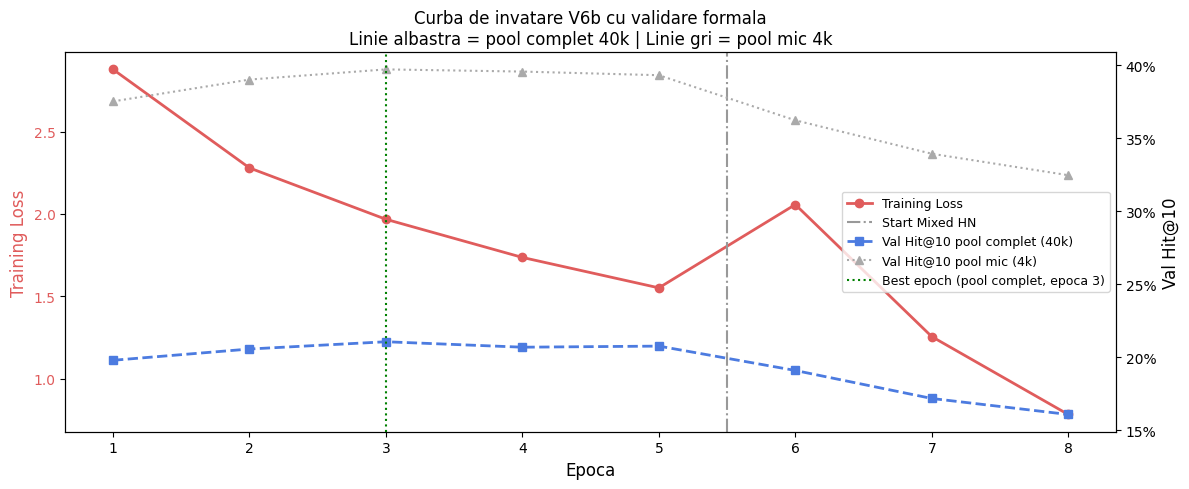

In [13]:
import matplotlib.pyplot as plt

hist_mnr = pd.DataFrame(history_mnr)
hist_hn  = pd.DataFrame(history_hn)

max_mnr_epoch = hist_mnr['epoch'].max()
hist_hn_plot  = hist_hn.copy()
hist_hn_plot['epoch'] = hist_hn_plot['epoch'] + max_mnr_epoch

all_epochs      = hist_mnr['epoch'].tolist()       + hist_hn_plot['epoch'].tolist()
all_loss        = hist_mnr['loss'].tolist()         + hist_hn_plot['loss'].tolist()
all_val10_full  = hist_mnr['val_hit10_full'].tolist() + hist_hn_plot['val_hit10_full'].tolist()
all_val10_small = hist_mnr['val_hit10_small'].tolist() + hist_hn_plot['val_hit10_small'].tolist()

fig, ax1 = plt.subplots(figsize=(12, 5))

color_loss  = '#e05c5c'
color_full  = '#4c7be0'
color_small = '#aaaaaa'

ax1.set_xlabel('Epoca', fontsize=12)
ax1.set_ylabel('Training Loss', color=color_loss, fontsize=12)
ax1.plot(all_epochs, all_loss, marker='o', color=color_loss, linewidth=2, label='Training Loss')
ax1.tick_params(axis='y', labelcolor=color_loss)
ax1.set_xticks(all_epochs)

ax2 = ax1.twinx()
ax2.set_ylabel('Val Hit@10', fontsize=12)
ax2.plot(all_epochs, all_val10_full,  marker='s', color=color_full,  linewidth=2,
         linestyle='--', label='Val Hit@10 pool complet (40k)')
ax2.plot(all_epochs, all_val10_small, marker='^', color=color_small, linewidth=1.5,
         linestyle=':',  label='Val Hit@10 pool mic (4k)')
ax2.tick_params(axis='y')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

ax1.axvline(x=max_mnr_epoch + 0.5, color='#999', linestyle='-.', linewidth=1.5,
            label='Start Mixed HN')

best_idx   = all_val10_full.index(max(all_val10_full))
best_epoch = all_epochs[best_idx]
ax2.axvline(x=best_epoch, color='green', linestyle=':', linewidth=1.5,
            label=f'Best epoch (pool complet, epoca {best_epoch})')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=9)

plt.title('Curba de invatare V6b cu validare formala\n'
          'Linie albastra = pool complet 40k | Linie gri = pool mic 4k', fontsize=12)
fig.tight_layout()
plt.savefig(OUTPUT_PATH + 'learning_curve_v6.png', dpi=150)
plt.show()